In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [14]:
import os
print(os.getcwd())

c:\Users\DELL\OneDrive\Desktop\apexplanet_data_analytics\notebooks


In [16]:
import pandas as pd
df = pd.read_csv("../data/Sample - Superstore.csv",encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [18]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [19]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.drop_duplicates(inplace=True)

df.duplicated().sum()

np.int64(0)

In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [23]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["Sales"] >= lower)
    &
    (df["Sales"] <= upper)
]

df.shape

(8827, 21)

In [24]:
df.to_csv(
    "../data/cleaned_superstore.csv",
    index=False
)

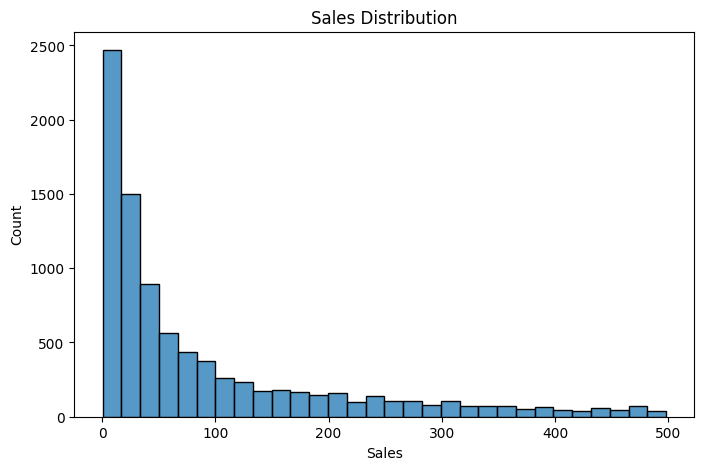

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=30
)

plt.title("Sales Distribution")

plt.show()

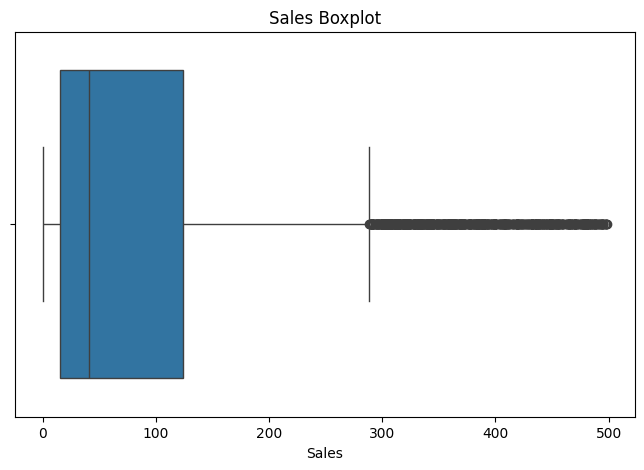

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Boxplot")

plt.show()

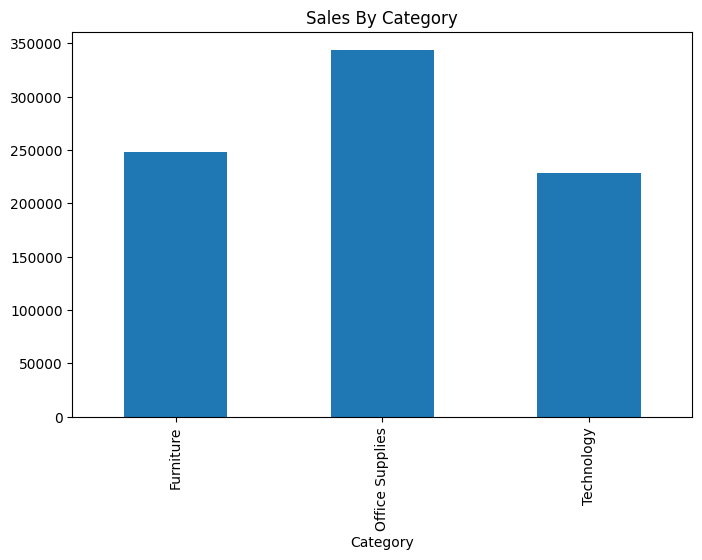

In [27]:
plt.figure(figsize=(8,5))

df.groupby("Category")["Sales"].sum().plot(
    kind="bar"
)

plt.title("Sales By Category")

plt.show()

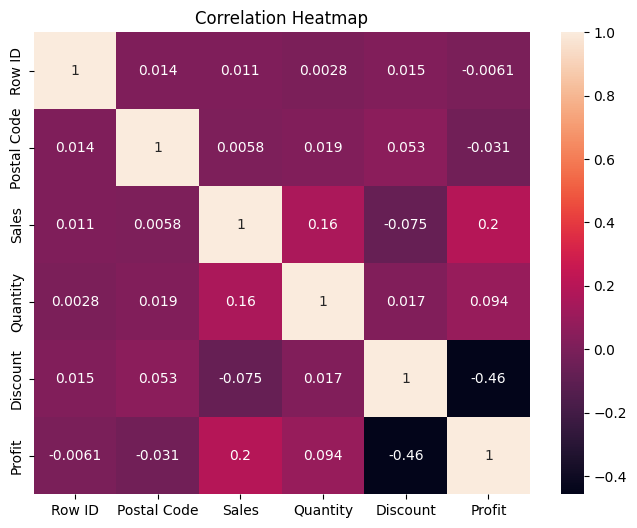

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

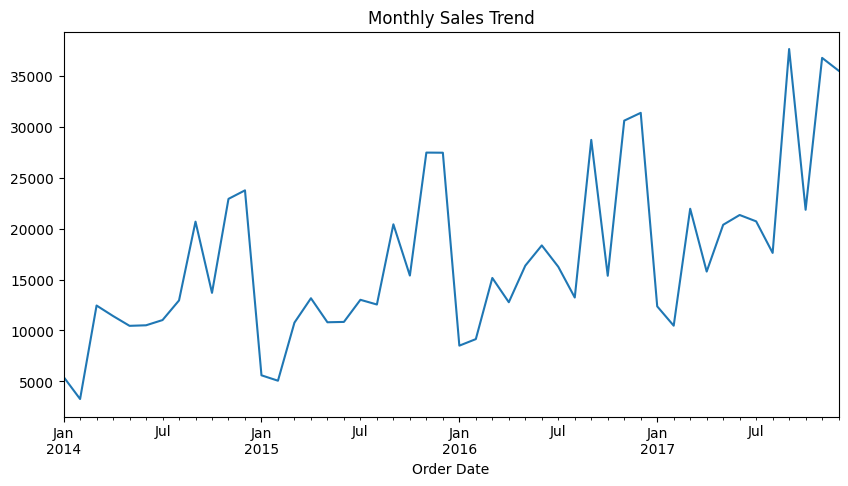

In [29]:
monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales.plot(
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")

plt.show()

Insight 1:
Technology category contributes the highest sales.

Insight 2:
Furniture contributes lower sales compared to Technology.

Insight 3:
Sales show fluctuations across different months.

Insight 4:
Most orders fall within lower sales ranges.

Insight 5:
Sales and Profit show a positive relationship.

In [8]:
import os
print(os.listdir("../data"))

['Sample - Superstore.csv']
